In [35]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [36]:
load_dotenv()
llm_model = ChatOpenAI(
    model = "gpt-4o-mini"
)

class ChatBotState(TypedDict):
    message:Annotated[list[BaseMessage],add_messages]

In [37]:
def process_user_message(state:ChatBotState)->dict:
    print(f'[process_user_message"]')
    userQuery = state['message']        
    llm_response=llm_model.invoke(userQuery)    
    return {'message':[llm_response]}

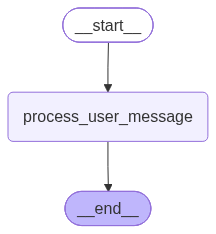

In [39]:
checkpointer = MemorySaver()
graph = StateGraph(ChatBotState)
graph.add_node("process_user_message",process_user_message)
graph.add_edge(START,"process_user_message")
graph.add_edge("process_user_message",END)
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [ ]:
thread_id ='1'
while True:
    user_message = input('Type your message')
    print('user: ',user_message)
    if user_message.strip().lower() in ['exit','bye','quit']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'message':[HumanMessage(content=user_message)]},config=config)
    print('AI: ',response['message'][-1].content)



user:  what is 10 plus 10
[process_user_message"]
AI:  10 plus 10 equals 20.
user:  what result plus 20
[process_user_message"]
AI:  Please provide a specific number that you'd like to add to 20, and I can help you find the result.
user:  add 20 to previous result
[process_user_message"]
AI:  The previous result was 20. Adding 20 to it gives you:

20 + 20 = 40.
user:  exit


In [46]:
chatbot.get_state(config={'configurable':{'thread_id':2}})

StateSnapshot(values={'message': [HumanMessage(content='what is 10 plus 10', additional_kwargs={}, response_metadata={}, id='3e9bd8fd-17bc-4131-a61d-74e64d4246c5'), AIMessage(content='10 plus 10 equals 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 14, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_25b7d0bd77', 'id': 'chatcmpl-EAxTZPdxhO06Yfn1pHySxWCseZPL6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe69f-120c-74d3-9c5c-9cae37f5f75f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 8, 'total_tokens': 22, 'input_token_details': {'aud